%share of AI roles with perk X = %share of perk X in general + %share of AI roles + log(size of occupation-year) + log(salary of AI roles)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
from IPython.core.display import HTML

In [3]:
import numpy as np

In [4]:
# import stargazer
from stargazer.stargazer import Stargazer

In [5]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [6]:
from package_files.benefits_defns import *

In [8]:
import importlib
import package_files.benefits_defns


In [9]:
importlib.reload(package_files.benefits_defns)


<module 'package_files.benefits_defns' from '/data/sant6443/SkillScale/package_files/benefits_defns.py'>

In [10]:
df = pd.read_csv('../exports/occ_year_coeff_analysis.csv')

In [10]:
pd.set_option('display.max_columns', None)

In [8]:
df[(df['Occupation']=="Architecture and Engineering Occupations") & (df['Year']==2019)]

,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI)
0,EDU_ASSISTANCE,Architecture and Engineering Occupations,2019,-0.378773,0.202133,0.061,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
90,WLB,Architecture and Engineering Occupations,2019,-0.155173,0.112814,0.169,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
180,PAID_LEAVE,Architecture and Engineering Occupations,2019,-0.303556,0.125737,0.016,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
270,HEALTH_WELLBEING,Architecture and Engineering Occupations,2019,-0.590114,0.272715,0.030,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
360,PARENTAL_LEAVE,Architecture and Engineering Occupations,2019,0.958254,0.256600,0.000,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
450,CULTURE,Architecture and Engineering Occupations,2019,0.568717,0.114443,0.000,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
540,wfh_wham,Architecture and Engineering Occupations,2019,0.366585,0.194626,0.060,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633


In [7]:
df

,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI)
0,EDU_ASSISTANCE,Architecture and Engineering Occupations,2019,-0.378773,0.202133,0.061,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.624130,3.144094,0.782428,1.972158,0.757758,5.568910,10.788863,5.460669,2.348773,3.415783,2.326330
1,EDU_ASSISTANCE,Architecture and Engineering Occupations,2021,-0.191725,0.140017,0.171,Architecture and Engineering Occupations,2021,2.278018,15.179062,-2.642404,11.521036,107050.060606,11.095518,73216.702324,103.835046,146.209891,61.420229,63.841780,73671.056972,42098,7.187990,5.839416,7.219427,20.221863,11.261731,20.430735,3.722267,2.294056,3.755560,2.598698,3.232534,2.583923,10.442301,24.400417,10.116921,8.357362,14.465409,8.215270
2,EDU_ASSISTANCE,Architecture and Engineering Occupations,2022,-0.309976,0.108110,0.004,Architecture and Engineering Occupations,2022,2.446456,7.394079,15.179062,11.600475,115932.657459,11.235284,83342.705232,103.250399,139.103545,54.149606,55.015043,83890.460953,57103,8.840166,6.800286,8.891322,22.760626,15.533286,22.941873,4.591703,2.219041,4.651205,3.991034,5.153901,3.961871,15.806525,35.146743,15.321509,14.685004,18.168605,14.597810
3,EDU_ASSISTANCE,Architecture and Engineering Occupations,2020,-0.152420,0.196615,0.438,Architecture and Engineering Occupations,2020,1.977806,-2.642404,24.871731,11.428493,100957.585366,11.075966,72630.480348,103.182813,139.001677,60.158371,59.307465,72858.029585,33522,5.271165,4.223228,5.292310,16.428017,9.502262,16.567759,2.890639,1.659125,2.915487,1.312571,1.357466,1.311665,6.691128,18.853695,6.445723,4.442167,13.698630,4.255188
4,EDU_ASSISTANCE,Architecture and Engineering Occupations,2018,0.043941,0.219785,0.842,Architecture and Engineering Occupations,2018,1.626858,NaN,NaN,11.279748,85233.255814,11.095357,72599.869117,101.661881,117.401390,64.000000,61.662382,72708.646776,40569,3.307944,3.333333,3.307525,8.255072,6.060606,8.291363,1.466637,1.818182,1.460823,0.276073,0.151515,0.278133,4.777047,7.121212,4.738280,0.000000,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,wfh_wham,Transportation and Material Moving Occupations,2019,-18.205488,17234.764550,0.999,Transportation and Material Moving Occupations,2019,0.033652,-18.600785,NaN,10.485831,38192.625000,10.591160,44183.609987,99.005500,86.440707,59.806452,61.214999,44182.104241,92120,4.829570,0.000000,4.831196,21.079027,12.903226,21.081780,3.222970,3.225806,3.222969,0.578593,0.000000,0.578788,2.248155,3.225806,2.247825,0.385060,0.000000,0.385194
611,wfh_wham,Transportation and Material Moving Occupations,2021,0.533101,0.527071,0.312,Transportation and Material Moving Occupations,2021,0.067199,149.616383,-20.001353,10.663532,48247.636364,10.664556,46919.891740,99.990403,102.829812,66.026549,65.484129,46920.261844,168157,7.579227,6.194690,7.580158,36.863764,11.504425,36.880817,7.994910,4.424779,7.997310,3.968315,5.

In [13]:
# add column for log job count
df['Log Job Count'] = df['job_count'].apply(lambda x: np.log(x))

%share of AI roles with perk X = %share of perk X in general + %share of AI roles + log(size of occupation-year) + log(salary of AI roles)

# Run Models

In [31]:

# benefit_models = {}
benefit_models = []
for benefit in benefits4:
    benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)

    label = benefits_labels_map[benefit]

    X = benefit_df[[f'Overall Benefit Prevalence', 'AI Demand', 'Log Job Count', 'Mean Log AI Salary']]
    y = benefit_df[f'Prevalence: {label} (AI)']

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    benefit_models.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.365
Model:                                             OLS   Adj. R-squared:                  0.335
Method:                                  Least Squares   F-statistic:                     12.23
Date:                                 Sun, 27 Oct 2024   Prob (F-statistic):           6.74e-08
Time:                                         20:13:36   Log-Likelihood:                -221.04
No. Observations:                                   90   AIC:                             452.1
Df Residuals:                                       85   BIC:                             464.6
Df Model:                                            4                                         
Covariance Type:                             nonrobust                                         
                         

# Display Results

In [27]:
stargazer = Stargazer(benefit_models)
display(HTML(stargazer.render_html()))

In [33]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(benefit_models)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column

with open(f'../exports/occ_year_final_model.tex', 'w') as f:
    f.write(stargazer.render_latex())
# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


In [17]:
# for benefit in benefits4:
#     stargazer = Stargazer(benefit_models[benefit])
#     stargazer.title(f'Coefficients for {benefits_labels_map[benefit]}')
#     display(HTML(stargazer.render_html()))
#     # # export to latex
#     # with open(f'../exports/occ_year_coeff_{benefit}.tex', 'w') as f:
#     #     f.write(stargazer.render_latex())

# Remote Keywords

In [71]:
df = pd.read_csv('../exports/occ_year_data/occ_year_analysis_remotekw.csv')

In [72]:
df

,SOC_2021_2_NAME,YEAR,AI Demand,MEAN SALARY,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,DURATION_CALC_ai,MEDIAN_LOG_SALARY_ai,MEDIAN_SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,DURATION_CALC_non_ai,MEDIAN_LOG_SALARY_non_ai,MEDIAN_SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,job_count,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI),Prevalence: Remote Keywords,Prevalence: Remote Keywords (AI),Prevalence: Remote Keywords (Non-AI),Log Job Count
0,Architecture and Engineering Occupations,2018,1.626858,72708.646776,NaN,NaN,11.279748,85233.255814,64.000000,11.329003,83200.0,11.095357,72599.869117,61.662382,11.156251,70000.0,101.661881,117.401390,40569,3.307944,3.333333,3.307525,8.255072,6.060606,8.291363,1.466637,1.818182,1.460823,0.276073,0.151515,0.278133,4.777047,7.121212,4.738280,0.000000,NaN,0.000000,1.971949,1.363636,1.982009,10.610760
1,Architecture and Engineering Occupations,2019,2.031486,73966.078049,24.871731,NaN,11.443344,97865.619048,61.510441,11.461632,95000.0,11.108535,73760.300943,59.027063,11.166484,70720.0,103.013976,132.680612,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.624130,3.144094,0.782428,1.972158,0.757758,5.568910,10.788863,5.460669,2.348773,3.415783,2.326330,2.104544,3.944316,2.066394,10.655658
2,Architecture and Engineering Occupations,2020,1.977806,72858.029585,-2.642404,24.871731,11.428493,100957.585366,60.158371,11.487608,97500.0,11.075966,72630.480348,59.307465,11.105859,66560.0,103.182813,139.001677,33522,5.271165,4.223228,5.292310,16.428017,9.502262,16.567759,2.890639,1.659125,2.915487,1.312571,1.357466,1.311665,6.691128,18.853695,6.445723,4.442167,13.698630,4.255188,3.872084,11.915535,3.709790,10.419957
3,Architecture and Engineering Occupations,2021,2.278018,73671.056972,15.179062,-2.642404,11.521036,107050.060606,61.420229,11.556942,104500.0,11.095518,73216.702324,63.841780,11.119883,67500.0,103.835046,146.209891,42098,7.187990,5.839416,7.219427,20.221863,11.261731,20.430735,3.722267,2.294056,3.755560,2.598698,3.232534,2.583923,10.442301,24.400417,10.116921,8.357362,14.465409,8.215270,6.670151,9.176225,6.611731,10.647756
4,Architecture and Engineering Occupations,2022,2.446456,83890.460953,7.394079,15.179062,11.600475,115932.657459,54.149606,11.556942,104500.0,11.235284,83342.705232,55.015043,11.277203,79000.0,103.250399,139.103545,57103,8.840166,6.800286,8.891322,22.760626,15.533286,22.941873,4.591703,2.219041,4.651205,3.991034,5.153901,3.961871,15.806525,35.146743,15.321509,14.685004,18.168605,14.597810,10.475807,13.886901,10.390263,10.952612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Transportation and Material Moving Occupations,2019,0.033652,44182.104241,-18.600785,NaN,10.485831,38192.625000,59.806452,10.450209,34663.0,10.591160,44183.609987,61.214999,10.473337,35360.0,99.005500,86.440707,92120,4.829570,0.000000,4.831196,21.079027,12.903226,21.081780,3.222970,3.225806,3.222969,0.578593,0.000000,0.578788,2.248155,3.225806,2.247825,0.385060,0.000000,0.385194,0.574251,0.000000,0.574444,11.430847
86,Transportation and Material Moving Occupations,2020,0.026921,42269.295590,-20.001353,-18.600785,10.529685,40678.900000,55.210526,10.404093,33020.0,10.562795,42269.527535,62.520019,10.425134,33696.0,99.686540,96.236940,141154,5.673945,5.263158,5.674055,29.072502,18.421053,29.075371,7.670346,2.6315

In [35]:
benefit_models = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df = benefit_df[benefit_df[f'Prevalence: {benefits_labels_map[benefit]} (AI)'].notna()]
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)

    label = benefits_labels_map[benefit]

    X = benefit_df[[f'Overall Benefit Prevalence', 'AI Demand', 'Log Job Count', 'MEDIAN SALARY_ai']]
    y = benefit_df[f'Prevalence: {label} (AI)']

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    benefit_models.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.365
Model:                                             OLS   Adj. R-squared:                  0.335
Method:                                  Least Squares   F-statistic:                     12.23
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           6.74e-08
Time:                                         16:22:52   Log-Likelihood:                -221.04
No. Observations:                                   90   AIC:                             452.1
Df Residuals:                                       85   BIC:                             464.6
Df Model:                                            4                                         
Covariance Type:                             nonrobust                                         
                         

In [32]:
benefit_models

In [36]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(benefit_models)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


# Model Configuration

## Baseline: Year and Overall Benefit Prevalence

In [46]:
baseline_models = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df = benefit_df[benefit_df[f'Prevalence: {benefits_labels_map[benefit]} (AI)'].notna()]
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]

    X = benefit_df[[f'Overall Benefit Prevalence']]
    y = benefit_df[f'Prevalence: {label} (AI)']
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    baseline_models.append(model)
    # Print the summary of the regression
    print(model.summary())

    Year_2018  Year_2020  Year_2021  Year_2022  Year_2023
0        True      False      False      False      False
1       False      False      False      False      False
2       False       True      False      False      False
3       False      False       True      False      False
4       False      False      False       True      False
..        ...        ...        ...        ...        ...
85      False      False      False      False      False
86      False       True      False      False      False
87      False      False       True      False      False
88      False      False      False       True      False
89      False      False      False      False       True

[90 rows x 5 columns]
    Overall Benefit Prevalence  Year_2018  Year_2020  Year_2021  Year_2022  \
0                     3.307944          1          0          0          0   
1                     4.645079          0          0          0          0   
2                     5.271165          0      

In [47]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(baseline_models)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## With AI Demand

In [51]:
models2 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df = benefit_df[benefit_df[f'Prevalence: {benefits_labels_map[benefit]} (AI)'].notna()]
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]

    X = benefit_df[[f'Overall Benefit Prevalence', 'AI Demand']]
    y = benefit_df[f'Prevalence: {label} (AI)']
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models2.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.554
Model:                                             OLS   Adj. R-squared:                  0.516
Method:                                  Least Squares   F-statistic:                     14.57
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           3.51e-12
Time:                                         16:46:07   Log-Likelihood:                -205.12
No. Observations:                                   90   AIC:                             426.2
Df Residuals:                                       82   BIC:                             446.2
Df Model:                                            7                                         
Covariance Type:                             nonrobust                                         
                         

In [50]:
models2

[]

In [52]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models2)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## + % Demand Change

In [56]:
models3 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'AI Demand', 'AI Demand % Change']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models3.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.579
Model:                                             OLS   Adj. R-squared:                  0.534
Method:                                  Least Squares   F-statistic:                     13.14
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           1.61e-10
Time:                                         16:57:25   Log-Likelihood:                -171.34
No. Observations:                                   75   AIC:                             358.7
Df Residuals:                                       67   BIC:                             377.2
Df Model:                                            7                                         
Covariance Type:                             nonrobust                                         
                         

In [57]:
models3

In [58]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models3)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## % Change Substitute for AI Demand

In [59]:
models3b = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'AI Demand % Change']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models3b.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.563
Model:                                             OLS   Adj. R-squared:                  0.525
Method:                                  Least Squares   F-statistic:                     14.62
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           1.22e-10
Time:                                         17:03:06   Log-Likelihood:                -172.67
No. Observations:                                   75   AIC:                             359.3
Df Residuals:                                       68   BIC:                             375.6
Df Model:                                            6                                         
Covariance Type:                             nonrobust                                         
                         

In [60]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models3b)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## Median Salary

In [79]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'AI Demand', 'MEDIAN_SALARY_ai']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.559
Model:                                             OLS   Adj. R-squared:                  0.516
Method:                                  Least Squares   F-statistic:                     12.85
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           9.23e-12
Time:                                         17:39:08   Log-Likelihood:                -204.63
No. Observations:                                   90   AIC:                             427.3
Df Residuals:                                       81   BIC:                             449.8
Df Model:                                            8                                         
Covariance Type:                             nonrobust                                         
                         

In [80]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


In [77]:
models_salary = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'MEDIAN_LOG_SALARY_ai']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    # X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models_salary.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.024
Model:                                             OLS   Adj. R-squared:                  0.013
Method:                                  Least Squares   F-statistic:                     2.129
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):              0.148
Time:                                         17:36:25   Log-Likelihood:                -240.42
No. Observations:                                   90   AIC:                             484.8
Df Residuals:                                       88   BIC:                             489.8
Df Model:                                            1                                         
Covariance Type:                             nonrobust                                         
                         

In [78]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models_salary)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


In [68]:
df['MEDIAN SALARY_ai'].describe()

count        90.000000
mean      80753.538889
std       37439.280812
min       20800.000000
25%       52525.000000
50%       74256.250000
75%      100000.000000
max      225000.000000
Name: MEDIAN SALARY_ai, dtype: float64

<Axes: >

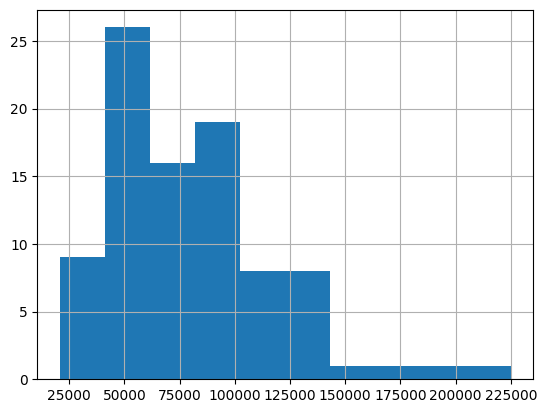

In [69]:
df['MEDIAN SALARY_ai'].hist()

<Axes: >

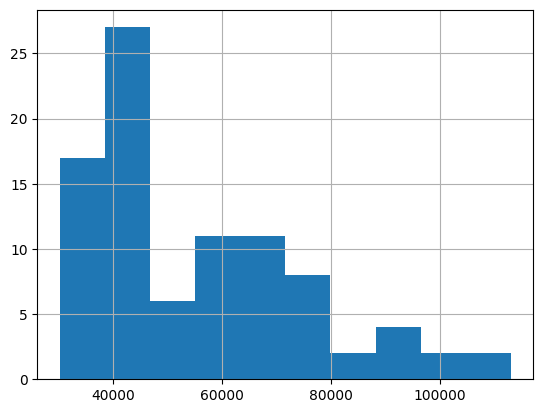

In [70]:
df['MEDIAN SALARY_non_ai'].hist()

<Axes: >

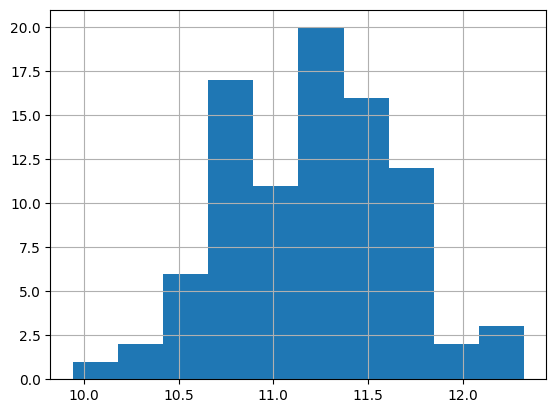

In [73]:
df['MEDIAN_LOG_SALARY_ai'].hist()

<Axes: >

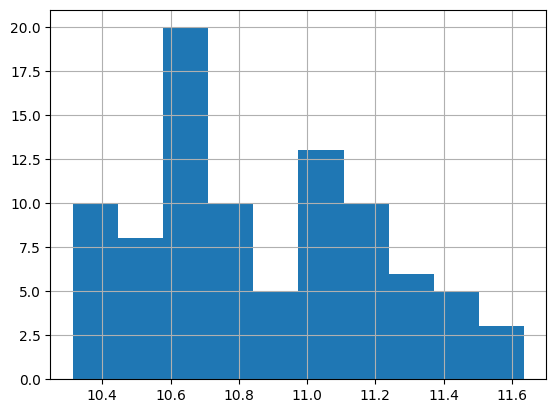

In [74]:
df['MEDIAN_LOG_SALARY_non_ai'].hist()

# Computer & Mathematical Occupations Dummy

In [82]:
df['Comp_Math_Occ'] = (df[occupation] == 'Computer and Mathematical Occupations').astype(int)

In [88]:
models5 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'AI Demand', 'Comp_Math_Occ']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models5.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.567
Model:                                             OLS   Adj. R-squared:                  0.524
Method:                                  Least Squares   F-statistic:                     13.24
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           4.82e-12
Time:                                         17:46:06   Log-Likelihood:                -203.86
No. Observations:                                   90   AIC:                             425.7
Df Residuals:                                       81   BIC:                             448.2
Df Model:                                            8                                         
Covariance Type:                             nonrobust                                         
                         

In [89]:
# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models5)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


# 2024

In [ ]:
df_24 = 

# Raw Numbers

In [7]:
df = pd.read_csv('../exports/occ_year_data/occ_year_analysis_2024_raw.csv')

In [19]:
pd.set_option('display.max_columns', None)

In [20]:
df

,SOC_2021_2_NAME,YEAR,AI Demand,MEAN SALARY,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,MEDIAN_LOG_SALARY_ai,MEDIAN_SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,MEDIAN_LOG_SALARY_non_ai,MEDIAN_SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,job_count,ai_role_count,AI Job Count Change,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI),Log Job Count
0,Architecture and Engineering Occupations,2018,1.761622,72795.246218,NaN,NaN,11.402916,101224.261905,11.407565,90000.0,11.091694,72480.367880,11.156251,70000.0,102.805895,139.657489,31278,551,NaN,1061,16,1045,2627,28,2599,461,9,452,114,3,111,1525,53,1472,594,11,583,10.350670
1,Architecture and Engineering Occupations,2019,1.858963,74853.379284,5.525650,NaN,11.460268,106851.375000,11.511674,100000.0,11.117763,74589.342187,11.185677,72090.5,103.080702,143.252872,32814,610,59.0,1463,17,1446,3836,48,3788,986,18,968,223,7,216,1826,58,1768,738,18,720,10.398611
2,Architecture and Engineering Occupations,2020,2.052311,72970.326775,10.400862,5.525650,11.484405,105972.333333,11.521687,100880.0,11.078528,72646.614940,11.115711,67219.0,103.663636,145.873739,25922,532,-78.0,1319,17,1302,4448,42,4406,728,9,719,339,9,330,1710,85,1625,1014,58,956,10.162847
3,Architecture and Engineering Occupations,2021,2.238034,74053.996015,9.049489,10.400862,11.514129,108507.432099,11.624914,111850.0,11.102735,73563.534095,11.121363,67600.0,103.705339,147.501657,32886,736,204.0,2386,45,2341,6813,106,6707,1261,27,1234,863,41,822,3453,175,3278,2264,87,2177,10.400802
4,Architecture and Engineering Occupations,2022,2.447608,83386.806735,9.364197,9.049489,11.687750,124993.617647,11.695247,120000.0,11.225629,82694.970779,11.258033,77500.0,104.116663,151.150205,43757,1071,335.0,3891,85,3806,9934,164,9770,2033,47,1986,1817,66,1751,6801,331,6470,4676,161,4515,10.686407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Transportation and Material Moving Occupations,2020,0.044357,42747.152531,2.267667,-23.731457,10.507093,42792.181818,10.348173,31200.0,10.572006,42747.142741,10.443484,34320.0,99.385989,100.105362,105958,47,16.0,5425,2,5423,30032,8,30024,7066,0,7066,1473,1,1472,2174,2,2172,650,2,648,11.570798
101,Transportation and Material Moving Occupations,2021,0.060855,46877.977122,37.193888,2.267667,10.762589,51940.611111,10.584476,39520.0,10.663019,46876.482176,10.530495,37440.0,100.933787,110.803133,129816,79,32.0,9686,3,9683,47659,13,47646,10334,2,10332,5067,0,5067,6820,31,6789,1016,2,1014,11.773873
102,Transportation and Material Moving Occupations,2022,0.084035,48768.269575,38.090075,37.193888,10.622847,44434.416667,10.530495,37440.0,10.708844,48770.400934,10.584562,39520.0,99.196954,91.109394,104718,88,9.0,8964,6,8958,39112,20,39092,5624,3,5621,6817,10,6807,9922,22,9900,1036,9,1027,11.559026
103,Transportation and Material Moving Occupations,2023,0.071828,51474.228189,-14.526213,38.090075,10.861613,60579.407407,10.635855,41600.0,10.760301,51468.565634,10.635855,41600.0,100.941530,117.701760,84925,61,-27.0,8323,2,8321,34483,13,34470,5254,2,5252,5562,4,5558,7475,11,7464,765,3,762,11.349524


In [12]:
# df[df[occupation]=='Computer and Mathematical Occupations']

,SOC_2021_2_NAME,YEAR,AI Demand,MEAN SALARY,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,MEDIAN_LOG_SALARY_ai,MEDIAN_SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,MEDIAN_LOG_SALARY_non_ai,MEDIAN_SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,job_count,ai_role_count,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI),Prevalence: Remote Keywords,Prevalence: Remote Keywords (AI),Prevalence: Remote Keywords (Non-AI),Log Job Count
28,Computer and Mathematical Occupations,2018,6.381569,91334.125123,NaN,NaN,11.619600,120019.515206,11.695247,120000.0,11.294346,89951.428473,11.379394,87500.0,102.879792,133.427025,137333,8764,376400,23600,352800,964700,66300,898400,174400,14000,160400,73500,9500,64000,828200,76400,751800,100.0,0.0,100.0,630700,24500,606200,11.830164
29,Computer and Mathematical Occupations,2019,7.335330,95298.656416,14.945564,NaN,11.703155,128171.008451,11.767258,128960.0,11.332830,93505.113809,11.429544,92000.0,103.267720,137.073795,145215,10652,406300,27200,379100,1327300,87700,1239600,271800,22200,249600,133600,16300,117300,907300,98200,809100,49000.0,3600.0,45400.0,708700,38100,670600,11.885971
30,Computer and Mathematical Occupations,2020,7.895580,99079.908324,7.637693,14.945564,11.719450,129179.282528,11.736069,125000.0,11.375376,97285.552486,11.500853,98800.0,103.024723,132.783624,121663,9606,371300,25900,345400,1212400,79400,1133000,247000,17900,229100,174700,20200,154500,814200,110400,703800,91500.0,9700.0,81800.0,1263200,95500,1167700,11.709010
31,Computer and Mathematical Occupations,2021,9.185663,102094.301477,16.339306,7.637693,11.703989,126819.572497,11.734468,124800.0,11.409764,100069.110797,11.512925,100000.0,102.578708,126.731987,136909,12576,646900,57200,589700,2143700,177400,1966300,465400,49600,415800,459800,61700,398100,1720400,249000,1471400,195700.0,20600.0,175100.0,2609800,246600,2363200,11.827072
32,Computer and Mathematical Occupations,2022,9.670945,108482.987778,5.283032,16.339306,11.759194,133827.127747,11.780277,130650.0,11.478853,106105.648016,11.561716,105000.0,102.442238,126.126300,156448,15130,1036400,108300,928100,2999100,300000,2699100,705500,81800,623700,839300,126200,713100,2820100,395300,2424800,294400.0,32700.0,261700.0,3771200,414500,3356700,11.960479
33,Computer and Mathematical Occupations,2023,8.953113,117023.198051,-7.422563,5.283032,11.827890,144750.626920,11.837325,138320.0,11.556938,114018.540217,11.631206,112556.0,102.344492,126.953587,97575,8736,934300,107800,826500,2426800,245700,2181100,577100,66100,511000,836500,117000,719500,1674600,212600,1462000,154700.0,14600.0,140100.0,2318100,235300,2082800,11.488377
34,Computer and Mathematical Occupations,2024,15.450629,122249.776413,72.572703,-7.422563,11.883150,153040.033821,11.901922,147550.0,11.573587,117015.552670,11.648391,114507.0,102.674741,130.786062,58496,9038,565200,84700,480500,1630700,220000,1410700,379000,65700,313300,673200,116300,556900,1056800,186800,870000,2400.0,200.0,2200.0,1201400,183900,1017500,10.976714


In [37]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'ai_role_count', 'MEDIAN_LOG_SALARY_ai', 'job_count']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                      features         VIF
0                        const  958.429578
1   Overall Benefit Prevalence    5.975228
2                ai_role_count    1.694413
3         MEDIAN_LOG_SALARY_ai    1.494240
4                    job_count    6.042657
5                    Year_2018    1.773982
6                    Year_2020    1.734287
7                    Year_2021    1.872800
8                    Year_2022    2.037914
9                    Year_2023    2.380081
10                   Year_2024    2.405174
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.799
Model:                                             OLS   Adj. R-squared:                  0.777
Method:                                  Least Squares   F-statistic:                     36.53
Date:                                 Mon, 11 Nov 2024   Prob (F-statisti

In [20]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## No Year Fixed Effects

In [21]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'ai_role_count', 'MEDIAN_LOG_SALARY_ai', 'job_count']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    # year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    # X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)

    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                     features         VIF
0                       const  903.274514
1  Overall Benefit Prevalence    3.821547
2               ai_role_count    1.656240
3        MEDIAN_LOG_SALARY_ai    1.375768
4                   job_count    4.209922
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.789
Model:                                             OLS   Adj. R-squared:                  0.781
Method:                                  Least Squares   F-statistic:                     91.70
Date:                                 Wed, 06 Nov 2024   Prob (F-statistic):           2.97e-32
Time:                                         16:37:32   Log-Likelihood:                -602.89
No. Observations:                                  103   AIC:                             1216.
Df Residuals:                                    

In [16]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## Log

In [22]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence', 'ai_role_count', f'Prevalence: {label} (AI)']
    # get log of X_cols
    for col in log_cols:
        benefit_df[f'{col} (Log)'] = benefit_df[col].apply(lambda x: np.log(x +1))
    X_cols = [f'{col} (Log)' for col in log_cols[:-1]] + ['MEDIAN_LOG_SALARY_ai', 'Log Job Count'] 
    y_col = [f'Prevalence: {label} (AI) (Log)']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                            features          VIF
0                              const  3231.590931
1   Overall Benefit Prevalence (Log)    16.844822
2                ai_role_count (Log)     4.300271
3               MEDIAN_LOG_SALARY_ai     3.212698
4                      Log Job Count    18.655656
5                          Year_2018     1.814412
6                          Year_2020     1.752502
7                          Year_2021     2.089738
8                          Year_2022     2.327466
9                          Year_2023     2.957516
10                         Year_2024     3.283091
                                        OLS Regression Results                                       
Dep. Variable:     Prevalence: Tuition Assistance (AI) (Log)   R-squared:                       0.908
Model:                                                   OLS   Adj. R-squared:                  0.898
Method:                                        Least Squares   F-st

In [23]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))

## Log No Year

In [24]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence', 'ai_role_count', f'Prevalence: {label} (AI)']
    # get log of X_cols
    for col in log_cols:
        benefit_df[f'{col} (Log)'] = benefit_df[col].apply(lambda x: np.log(x +1))
    X_cols = [f'{col} (Log)' for col in log_cols[:-1]] + ['MEDIAN_LOG_SALARY_ai', 'Log Job Count'] 
    y_col = [f'Prevalence: {label} (AI) (Log)']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    # year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    # X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                           features          VIF
0                             const  3029.150136
1  Overall Benefit Prevalence (Log)     6.510197
2               ai_role_count (Log)     4.160153
3              MEDIAN_LOG_SALARY_ai     3.088060
4                     Log Job Count     8.921733
                                        OLS Regression Results                                       
Dep. Variable:     Prevalence: Tuition Assistance (AI) (Log)   R-squared:                       0.883
Model:                                                   OLS   Adj. R-squared:                  0.878
Method:                                        Least Squares   F-statistic:                     184.5
Date:                                       Wed, 06 Nov 2024   Prob (F-statistic):           1.05e-44
Time:                                               16:38:09   Log-Likelihood:                -86.203
No. Observations:                                        103   AIC:

In [25]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))

In [20]:
df['Log AI Job Change'] = df['AI Job Count Change'].apply(lambda x: np.log(x +1))

/tmp/ipykernel_1491328/3714777978.py:1: RuntimeWarning: invalid value encountered in log
  df['Log AI Job Change'] = df['AI Job Count Change'].apply(lambda x: np.log(x +1))


In [19]:
df['AI Job Count Change'].describe()

count      90.000000
mean       30.555556
std       868.737662
min     -6394.000000
25%        -8.000000
50%        22.000000
75%        78.500000
max      2970.000000
Name: AI Job Count Change, dtype: float64

In [22]:
df['Log AI Job Change'].value_counts(dropna=False)

Log AI Job Change
NaN         44
2.484907     2
3.583519     2
2.197225     2
4.158883     2
3.401197     2
3.828641     2
4.406719     2
1.386294     2
5.817111     1
4.276666     1
4.762174     1
5.323010     1
4.094345     1
5.958425     1
6.753438     1
4.912655     1
2.772589     1
7.543803     1
7.996654     1
4.174387     1
4.532599     1
5.713733     1
7.845808     1
2.944439     1
4.262680     1
3.433987     1
3.931826     1
5.003946     1
3.332205     1
3.737670     1
1.791759     1
2.639057     1
4.882802     1
5.129899     1
5.894403     1
6.959399     1
3.295837     1
6.563856     1
4.219508     1
5.327876     1
5.384495     1
1.945910     1
2.564949     1
1.609438     1
3.891820     1
3.713572     1
5.278115     1
3.610918     1
4.521789     1
2.833213     1
3.496508     1
2.302585     1
2.079442     1
Name: count, dtype: int64

## Change in Demand

In [23]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence', f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=log_cols)
    # get log of X_cols
    for col in log_cols:
        benefit_df[f'{col} (Log)'] = benefit_df[col].apply(lambda x: np.log(x +1))
    X_cols = [f'{col} (Log)' for col in log_cols[:-1]] + ['MEDIAN_LOG_SALARY_ai', 'Log Job Count', 'AI Job Count Change'] 
    y_col = [f'Prevalence: {label} (AI) (Log)']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                           features          VIF
0                             const  1110.553236
1  Overall Benefit Prevalence (Log)    15.156557
2              MEDIAN_LOG_SALARY_ai     1.157268
3                     Log Job Count    14.684552
4               AI Job Count Change     1.211486
5                         Year_2020     1.724989
6                         Year_2021     2.096524
7                         Year_2022     2.369804
8                         Year_2023     3.176261
9                         Year_2024     3.451875
                                        OLS Regression Results                                       
Dep. Variable:     Prevalence: Tuition Assistance (AI) (Log)   R-squared:                       0.747
Model:                                                   OLS   Adj. R-squared:                  0.718
Method:                                        Least Squares   F-statistic:                     25.60
Date:                     

In [24]:
# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))

### Log Change

In [46]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence', 'AI Job Count Change','ai_role_count', f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=log_cols)
    # get log of X_cols
    for col in log_cols:
        benefit_df[f'{col} (Log)'] = benefit_df[col].apply(lambda x: np.sign(x) * np.log(abs(x) + 1))
    X_cols = [f'{col} (Log)' for col in log_cols[:-1]] + ['MEDIAN_LOG_SALARY_ai', 'Log Job Count'] 
    y_col = [f'Prevalence: {label} (AI) (Log)']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                            features          VIF
0                              const  3796.732089
1   Overall Benefit Prevalence (Log)    16.697430
2          AI Job Count Change (Log)     2.453925
3                ai_role_count (Log)     4.827536
4               MEDIAN_LOG_SALARY_ai     3.682950
5                      Log Job Count    19.860217
6                          Year_2020     2.199983
7                          Year_2021     2.195178
8                          Year_2022     2.426018
9                          Year_2023     3.721399
10                         Year_2024     3.476036
                                        OLS Regression Results                                       
Dep. Variable:     Prevalence: Tuition Assistance (AI) (Log)   R-squared:                       0.922
Model:                                                   OLS   Adj. R-squared:                  0.912
Method:                                        Least Squares   F-st

In [47]:
# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column

# export to latex table
with open(f'../exports/tables/occ_year_model_log_raw.tex', 'w') as f:
    f.write(stargazer.render_latex())


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))

### Without Years

In [48]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence', 'AI Job Count Change', 'ai_role_count', f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=log_cols)
    # get log of X_cols
    for col in log_cols:
        benefit_df[f'{col} (Log)'] = benefit_df[col].apply(lambda x: np.sign(x) * np.log(abs(x) + 1))
    X_cols = [f'{col} (Log)' for col in log_cols[:-1]] + ['MEDIAN_LOG_SALARY_ai', 'Log Job Count'] 
    y_col = [f'Prevalence: {label} (AI) (Log)']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    # year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    # X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                           features          VIF
0                             const  3629.375401
1  Overall Benefit Prevalence (Log)     7.700306
2         AI Job Count Change (Log)     1.054079
3               ai_role_count (Log)     4.774011
4              MEDIAN_LOG_SALARY_ai     3.595454
5                     Log Job Count    10.821971
                                        OLS Regression Results                                       
Dep. Variable:     Prevalence: Tuition Assistance (AI) (Log)   R-squared:                       0.898
Model:                                                   OLS   Adj. R-squared:                  0.892
Method:                                        Least Squares   F-statistic:                     144.8
Date:                                       Mon, 11 Nov 2024   Prob (F-statistic):           3.58e-39
Time:                                               14:51:43   Log-Likelihood:                -68.483
No. Observations: 

In [49]:
# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))

# Balanced Sample Differences

In [8]:
diffs = pd.read_csv('../exports/occ_year_data/balanced_sample_diffs.csv')

In [9]:
diffs

,SOC_2021_2_NAME,YEAR,EDU_ASSISTANCE_difference,PAID_LEAVE_difference,HEALTH_WELLBEING_difference,PARENTAL_LEAVE_difference,CULTURE_difference,REMOTE_KW_difference
0,Architecture and Engineering Occupations,2018,-8,-11,2,3,21,2
1,Architecture and Engineering Occupations,2019,-10,-25,2,4,23,2
2,Architecture and Engineering Occupations,2020,-3,-39,-1,3,56,39
3,Architecture and Engineering Occupations,2021,-17,-54,-8,15,95,40
4,Architecture and Engineering Occupations,2022,-13,-79,-2,32,176,32
...,...,...,...,...,...,...,...,...
100,Transportation and Material Moving Occupations,2020,0,-1,-3,0,2,2
101,Transportation and Material Moving Occupations,2021,-7,-21,-8,-3,29,2
102,Transportation and Material Moving Occupations,2022,-1,-25,-2,5,11,9
103,Transportation and Material Moving Occupations,2023,-9,-11,-3,1,4,3


In [10]:
df

,SOC_2021_2_NAME,YEAR,AI Demand,MEAN SALARY,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,MEDIAN_LOG_SALARY_ai,MEDIAN_SALARY_ai,...,Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI),Log Job Count
0,Architecture and Engineering Occupations,2018,1.761622,72795.246218,NaN,NaN,11.402916,101224.261905,11.407565,90000.0,...,114,3,111,1525,53,1472,594,11,583,10.350670
1,Architecture and Engineering Occupations,2019,1.858963,74853.379284,5.525650,NaN,11.460268,106851.375000,11.511674,100000.0,...,223,7,216,1826,58,1768,738,18,720,10.398611
2,Architecture and Engineering Occupations,2020,2.052311,72970.326775,10.400862,5.525650,11.484405,105972.333333,11.521687,100880.0,...,339,9,330,1710,85,1625,1014,58,956,10.162847
3,Architecture and Engineering Occupations,2021,2.238034,74053.996015,9.049489,10.400862,11.514129,108507.432099,11.624914,111850.0,...,863,41,822,3453,175,3278,2264,87,2177,10.400802
4,Architecture and Engineering Occupations,2022,2.447608,83386.806735,9.364197,9.049489,11.687750,124993.617647,11.695247,120000.0,...,1817,66,1751,6801,331,6470,4676,161,4515,10.686407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Transportation and Material Moving Occupations,2020,0.044357,42747.152531,2.267667,-23.731457,10.507093,42792.181818,10.348173,31200.0,...,1473,1,1472,2174,2,2172,650,2,648,11.570798
101,Transportation and Material Moving Occupations,2021,0.060855,46877.977122,37.193888,2.267667,10.762589,51940.611111,10.584476,39520.0,...,5067,0,5067,6820,31,6789,1016,2,1014,11.773873
102,Transportation and Material Moving Occupations,2022,0.084035,48768.269575,38.090075,37.193888,10.622847,44434.416667,10.530495,37440.0,...,6817,10,6807,9922,22,9900,1036,9,1027,11.559026
103,Transportation and Material Moving Occupations,2023,0.071828,51474.228189,-14.526213,38.090075,10.861613,60579.407407,10.635855,41600.0,...,5562,4,5558,7475,11,7464,765,3,762,11.349524


In [11]:
df = df.merge(diffs, on=[occupation, 'YEAR'])

In [12]:
diff_models = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns = {f'ai_role_count': 'AI Job Count', 'MEDIAN_LOG_SALARY_ai': 'Median Log Salary AI'}, inplace=True)
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence']
    benefit_df = benefit_df.dropna(subset=log_cols)
    # get log of X_cols
    for col in log_cols:
        benefit_df[f'Log {col}'] = benefit_df[col].apply(lambda x: np.sign(x) * np.log(abs(x) + 1))
    X_cols = [f'Log {col}' for col in log_cols] + ['Median Log Salary AI', 'Log Job Count'] 
    y_col = [f'{benefit}_difference']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    X = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    diff_models.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                         features          VIF
0                           const  1071.280169
1  Log Overall Benefit Prevalence    15.816192
2            Median Log Salary AI     1.147155
3                   Log Job Count    14.571829
4                       Year_2018     1.800221
5                       Year_2020     1.751921
6                       Year_2021     2.074955
7                       Year_2022     2.316961
8                       Year_2023     2.956773
9                       Year_2024     3.269509
                                OLS Regression Results                               
Dep. Variable:     EDU_ASSISTANCE_difference   R-squared:                       0.144
Model:                                   OLS   Adj. R-squared:                  0.061
Method:                        Least Squares   F-statistic:                     1.741
Date:                       Tue, 12 Nov 2024   Prob (F-statistic):             0.0905
Time:                     

In [13]:
# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(diff_models)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))

In [14]:
html_table = stargazer.render_html()  # Render HTML for Word

with open("../exports/tables/difference_regression_table.html", "w") as f:
    f.write(html_table)

In [15]:
diff_models_2 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns = {f'ai_role_count': 'AI Job Count', 'MEDIAN_LOG_SALARY_ai': 'Median Log Salary AI'}, inplace=True)
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence', 'AI Job Count']
    benefit_df = benefit_df.dropna(subset=log_cols)
    # get log of X_cols
    for col in log_cols:
        benefit_df[f'Log {col}'] = benefit_df[col].apply(lambda x: np.sign(x) * np.log(abs(x) + 1))
    X_cols = [f'Log {col}' for col in log_cols] + ['Median Log Salary AI', 'Log Job Count'] 
    y_col = [f'{benefit}_difference']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    X = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    diff_models_2.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                          features          VIF
0                            const  3231.590931
1   Log Overall Benefit Prevalence    16.844822
2                 Log AI Job Count     4.300271
3             Median Log Salary AI     3.212698
4                    Log Job Count    18.655656
5                        Year_2018     1.814412
6                        Year_2020     1.752502
7                        Year_2021     2.089738
8                        Year_2022     2.327466
9                        Year_2023     2.957516
10                       Year_2024     3.283091
                                OLS Regression Results                               
Dep. Variable:     EDU_ASSISTANCE_difference   R-squared:                       0.166
Model:                                   OLS   Adj. R-squared:                  0.076
Method:                        Least Squares   F-statistic:                     1.837
Date:                       Tue, 12 Nov 2024   Prob (

In [24]:
[1]*len(benefits4)

[1, 1, 1, 1, 1, 1]

In [16]:
# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(diff_models_2)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` : each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))

In [17]:
html_table = stargazer.render_html()  # Render HTML for Word

with open("../exports/tables/difference_regression_table_2.html", "w") as f:
    f.write(html_table)

In [23]:
benefit_labels

['Tuition Assistance',
 'Paid Leave',
 'Health and Wellbeing',
 'Parental Leave',
 'Workplace Culture',
 'Remote Work']

In [27]:
combined_models = []
for model_a, model_b in zip(diff_models, diff_models_2):
    combined_models.extend([model_a, model_b])

# Create the Stargazer table
stargazer = Stargazer(combined_models)

# Set up the custom column labels for the top row (spanning two models per benefit)
benefit_labels = []
model_counts = []
for label in benefits4_labels:
    benefit_labels.append(label)
    model_counts.append(2)  # Each benefit spans two columns

# Apply custom columns for the top row (benefits)
stargazer.custom_columns(benefit_labels, model_counts)

# Add the second row for "A" and "B"
# stargazer.add_line(["A", "B"] * len(benefits4_labels))

# Render the table
display(HTML(stargazer.render_html()))

In [28]:
html_table = stargazer.render_html()  # Render HTML for Word

with open("../exports/tables/difference_regression_table_combined.html", "w") as f:
    f.write(html_table)

## Absolute Numbers

In [30]:
diff_models_abs = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns = {f'ai_role_count': 'AI Job Count', 'MEDIAN_LOG_SALARY_ai': 'Median Log Salary AI'}, inplace=True)
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence']
    benefit_df = benefit_df.dropna(subset=log_cols)
    # get log of X_cols
    # for col in log_cols:
    #     benefit_df[f'Log {col}'] = benefit_df[col].apply(lambda x: np.sign(x) * np.log(abs(x) + 1))
    X_cols = ['Overall Benefit Prevalence','Median Log Salary AI', 'Log Job Count'] 
    y_col = [f'{benefit}_difference']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    X = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    diff_models_abs.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                     features          VIF
0                       const  1071.966236
1  Overall Benefit Prevalence     2.918197
2        Median Log Salary AI     1.140104
3               Log Job Count     2.635744
4                   Year_2018     1.776185
5                   Year_2020     1.735334
6                   Year_2021     1.852140
7                   Year_2022     1.976398
8                   Year_2023     2.137742
9                   Year_2024     2.143249
                                OLS Regression Results                               
Dep. Variable:     EDU_ASSISTANCE_difference   R-squared:                       0.147
Model:                                   OLS   Adj. R-squared:                  0.064
Method:                        Least Squares   F-statistic:                     1.777
Date:                       Tue, 12 Nov 2024   Prob (F-statistic):             0.0830
Time:                               23:38:59   Log-Likelihood:        

In [31]:
diff_models_abs_2 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns = {f'ai_role_count': 'AI Job Count', 'MEDIAN_LOG_SALARY_ai': 'Median Log Salary AI'}, inplace=True)
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    log_cols = [f'Overall Benefit Prevalence']
    benefit_df = benefit_df.dropna(subset=log_cols)
    # get log of X_cols
    # for col in log_cols:
    #     benefit_df[f'Log {col}'] = benefit_df[col].apply(lambda x: np.sign(x) * np.log(abs(x) + 1))
    X_cols = ['Overall Benefit Prevalence','Median Log Salary AI', 'Log Job Count', 'AI Job Count'] 
    y_col = [f'{benefit}_difference']
    
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    X = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X).fit()
    print(benefit)
    print("VIF Results")
    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append(vif)
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = vif_data
    print(vif)
    # benefit_models.setdefault(benefit, []).append(model)
    diff_models_abs_2.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
VIF Results
                      features          VIF
0                        const  1741.177485
1   Overall Benefit Prevalence     3.269590
2         Median Log Salary AI     1.571416
3                Log Job Count     3.361719
4                 AI Job Count     1.691475
5                    Year_2018     1.776538
6                    Year_2020     1.735380
7                    Year_2021     1.856751
8                    Year_2022     1.986790
9                    Year_2023     2.137795
10                   Year_2024     2.143370
                                OLS Regression Results                               
Dep. Variable:     EDU_ASSISTANCE_difference   R-squared:                       0.190
Model:                                   OLS   Adj. R-squared:                  0.102
Method:                        Least Squares   F-statistic:                     2.161
Date:                       Tue, 12 Nov 2024   Prob (F-statistic):             0.0272
Time:          

In [32]:
combined_models = []
for model_a, model_b in zip(diff_models_abs, diff_models_abs_2):
    combined_models.extend([model_a, model_b])

# Create the Stargazer table
stargazer = Stargazer(combined_models)

# Set up the custom column labels for the top row (spanning two models per benefit)
benefit_labels = []
model_counts = []
for label in benefits4_labels:
    benefit_labels.append(label)
    model_counts.append(2)  # Each benefit spans two columns

# Apply custom columns for the top row (benefits)
stargazer.custom_columns(benefit_labels, model_counts)

# Add the second row for "A" and "B"
# stargazer.add_line(["A", "B"] * len(benefits4_labels))

# Render the table
display(HTML(stargazer.render_html()))

In [33]:
html_table = stargazer.render_html()  # Render HTML for Word

with open("../exports/tables/difference_regression_table_combined_absolute.html", "w") as f:
    f.write(html_table)

# Correlations

In [ ]:
# select all columns beginning with Prevalence: 
prevalence_cols = [col for col in df.columns if col.startswith('Prevalence: ')]
df_prevalence = df[prevalence_cols + ['MEAN SALARY']]

In [ ]:
df_prevalence

,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,...,Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI),Prevalence: Remote Keywords,Prevalence: Remote Keywords (AI),Prevalence: Remote Keywords (Non-AI),MEAN SALARY
0,1061,16,1045,2627,28,2599,461,9,452,114,...,1525,53,1472,0.0,0.0,0.0,594,11,583,72795.246218
1,1463,17,1446,3836,48,3788,986,18,968,223,...,1826,58,1768,35.0,1.0,34.0,738,18,720,74853.379284
2,1319,17,1302,4448,42,4406,728,9,719,339,...,1710,85,1625,71.0,3.0,68.0,1014,58,956,72970.326775
3,2386,45,2341,6813,106,6707,1261,27,1234,863,...,3453,175,3278,158.0,4.0,154.0,2264,87,2177,74053.996015
4,3891,85,3806,9934,164,9770,2033,47,1986,1817,...,6801,331,6470,306.0,4.0,302.0,4676,161,4515,83386.806735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,5425,2,5423,30032,8,30024,7066,0,7066,1473,...,2174,2,2172,35.0,0.0,35.0,650,2,648,42747.152531
101,9686,3,9683,47659,13,47646,10334,2,10332,5067,...,6820,31,6789,47.0,0.0,47.0,1016,2,1014,46877.977122
102,8964,6,8958,39112,20,39092,5624,3,5621,6817,...,9922,22,9900,36.0,1.0,35.0,1036,9,1027,48768.269575
103,8323,2,8321,34483,13,34470,5254,2,5252,5562,...,7475,11,7464,34.0,0.0,34.0,765,3,762,51474.228189


In [ ]:
correlation_matrix = df_prevalence.corr()

In [ ]:
correlation_matrix

,Prevalence: Tuition Assistance,Prevalence: Paid Leave,Prevalence: Health and Wellbeing,Prevalence: Parental Leave,Prevalence: Workplace Culture,Prevalence: Remote Work,MEAN SALARY
Prevalence: Tuition Assistance,1.000000,0.728160,0.747710,0.710566,0.681205,0.198934,0.302153
Prevalence: Paid Leave,0.728160,1.000000,0.821199,0.826273,0.588488,0.332908,0.061352
Prevalence: Health and Wellbeing,0.747710,0.821199,1.000000,0.799309,0.665764,0.361631,0.170931
Prevalence: Parental Leave,0.710566,0.826273,0.799309,1.000000,0.840941,0.615655,0.364900
Prevalence: Workplace Culture,0.681205,0.588488,0.665764,0.840941,1.000000,0.720926,0.541894
Prevalence: Remote Work,0.198934,0.332908,0.361631,0.615655,0.720926,1.000000,0.593625
MEAN SALARY,0.302153,0.061352,0.170931,0.364900,0.541894,0.593625,1.000000


In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

Text(0.5, -0.15, 'Correlation Matrix of Benefits Prevalence on Occupation-Year Level')

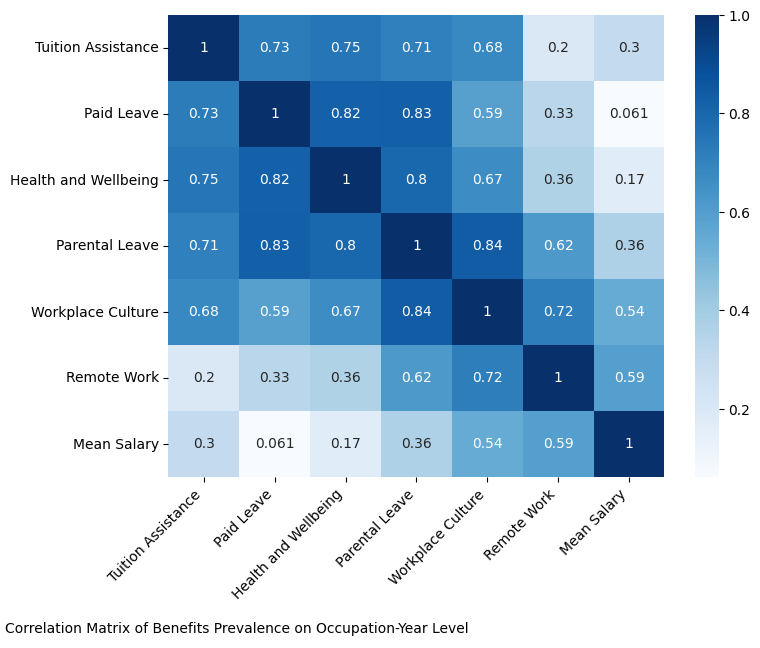

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', cbar = True)
plt.xticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Mean Salary'], rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Mean Salary'], rotation=0, va='center')
plt.figtext(0.5, -0.15, 'Correlation Matrix of Benefits Prevalence on Occupation-Year Level', wrap=True, horizontalalignment='right', fontsize=10)

## Median Salary

In [ ]:
# select all columns beginning with Prevalence: 
prevalence_cols = [col for col in df.columns if col.startswith('Prevalence') and col.endswith('(AI)')]
df_prevalence = df[prevalence_cols + ['MEDIAN_LOG_SALARY_ai']]

In [ ]:
df_prevalence

,Prevalence: Tuition Assistance (AI),Prevalence: Paid Leave (AI),Prevalence: Health and Wellbeing (AI),Prevalence: Parental Leave (AI),Prevalence: Workplace Culture (AI),Prevalence: Remote Work (AI),MEDIAN_LOG_SALARY_ai
0,16,28,9,3,53,11,11.407565
1,17,48,18,7,58,18,11.511674
2,17,42,9,9,85,58,11.521687
3,45,106,27,41,175,87,11.624914
4,85,164,47,66,331,161,11.695247
...,...,...,...,...,...,...,...
100,2,8,0,1,2,2,10.348173
101,3,13,2,0,31,2,10.584476
102,6,20,3,10,22,9,10.530495
103,2,13,2,4,11,3,10.635855


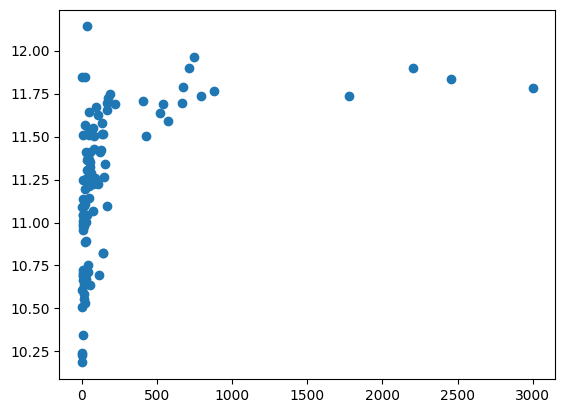

In [ ]:
plt.scatter(df['Prevalence: Paid Leave (AI)'], df['MEDIAN_LOG_SALARY_ai'])

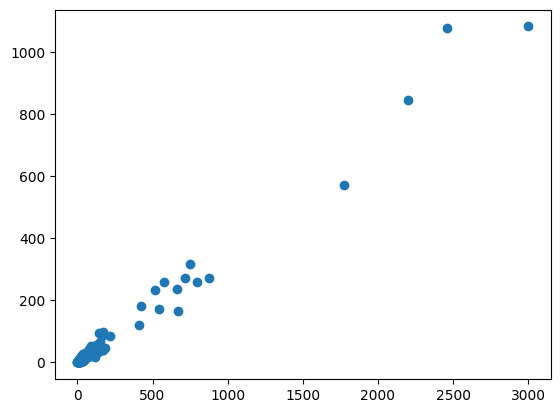

In [ ]:
plt.scatter(df['Prevalence: Paid Leave (AI)'], df['Prevalence: Tuition Assistance (AI)'])

In [ ]:
remove_outliers(df, 'Prevalence: Paid Leave (AI)')[['Prevalence: Paid Leave (AI)','Prevalence: Tuition Assistance (AI)']].corr()

,Prevalence: Paid Leave (AI),Prevalence: Tuition Assistance (AI)
Prevalence: Paid Leave (AI),1.00000,0.89002
Prevalence: Tuition Assistance (AI),0.89002,1.00000


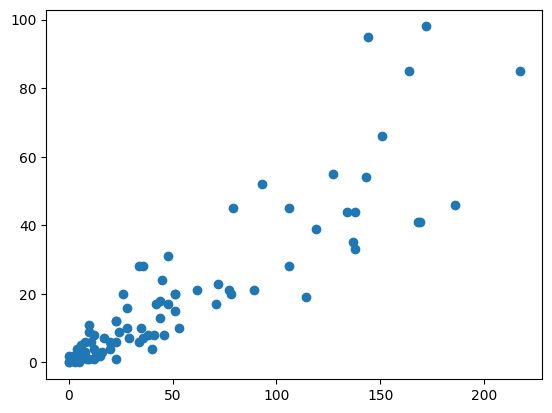

In [ ]:
plt.scatter(remove_outliers(df, 'Prevalence: Paid Leave (AI)')['Prevalence: Paid Leave (AI)'], remove_outliers(df,'Prevalence: Tuition Assistance (AI)')['Prevalence: Tuition Assistance (AI)'])

In [ ]:
correlation_matrix = df_prevalence.corr()

In [ ]:
correlation_matrix

,Prevalence: Tuition Assistance (AI),Prevalence: Paid Leave (AI),Prevalence: Health and Wellbeing (AI),Prevalence: Parental Leave (AI),Prevalence: Workplace Culture (AI),Prevalence: Remote Work (AI),MEDIAN_LOG_SALARY_ai
Prevalence: Tuition Assistance (AI),1.000000,0.990760,0.987275,0.985157,0.938901,0.941085,0.443881
Prevalence: Paid Leave (AI),0.990760,1.000000,0.996308,0.979664,0.969753,0.964036,0.450912
Prevalence: Health and Wellbeing (AI),0.987275,0.996308,1.000000,0.984266,0.965641,0.962465,0.446243
Prevalence: Parental Leave (AI),0.985157,0.979664,0.984266,1.000000,0.921775,0.939393,0.414061
Prevalence: Workplace Culture (AI),0.938901,0.969753,0.965641,0.921775,1.000000,0.980987,0.454336
Prevalence: Remote Work (AI),0.941085,0.964036,0.962465,0.939393,0.980987,1.000000,0.386677
MEDIAN_LOG_SALARY_ai,0.443881,0.450912,0.446243,0.414061,0.454336,0.386677,1.000000


Text(0.5, -0.15, 'Correlation Matrix of Benefits Prevalence on Occupation-Year Level')

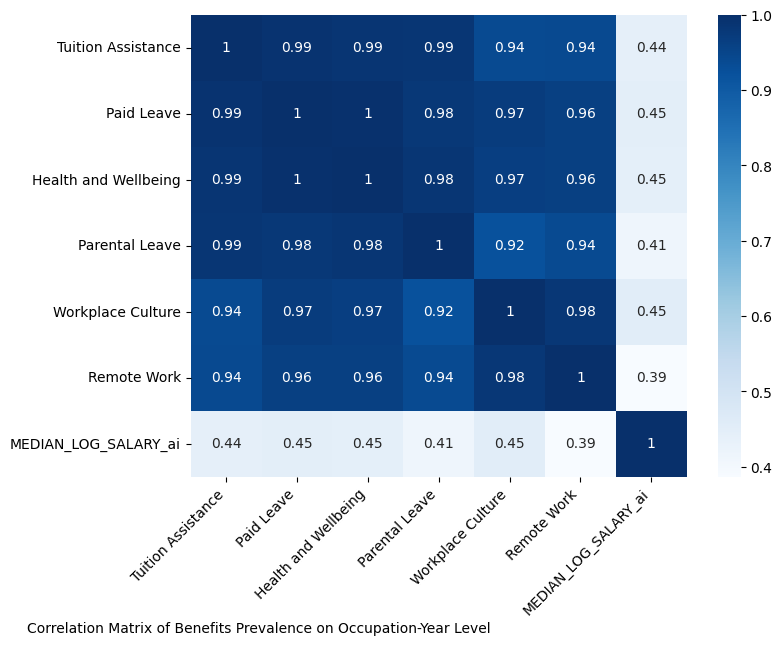

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', cbar = True)
plt.xticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['MEDIAN_LOG_SALARY_ai'], rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['MEDIAN_LOG_SALARY_ai'], rotation=0, va='center')
plt.figtext(0.5, -0.15, 'Correlation Matrix of Benefits Prevalence on Occupation-Year Level', wrap=True, horizontalalignment='right', fontsize=10)